# Phase 0: Mathematical & Computational Foundations  
## Notebook 00_01 — Probability, Filtrations, and Martingales in Discrete Time

### Research question

How can we represent the flow of information in a discrete-time financial model, and how can we computationally test whether a process behaves like a martingale?

This notebook introduces three foundational ideas:

1. **Filtrations** — how information accumulates through time.
2. **Adapted processes** — processes whose current value is known using current information.
3. **Martingales** — processes where the conditional expected future value equals the current value.

The goal is not to build a realistic market model yet. Instead, this notebook builds the probability framework needed for later topics such as binomial pricing, risk-neutral measures, Black-Scholes-Merton, stochastic calculus, and no-arbitrage derivative pricing.

## 1. Theory

Let

$$
(\Omega, \mathcal F, \mathbb P)
$$

be a probability space.

A **filtration** is an increasing sequence of sigma-algebras:

$$
\mathcal F_0 \subseteq \mathcal F_1 \subseteq \cdots \subseteq \mathcal F_n
$$

where $\mathcal F_n$ represents all information available up to time $n$.

A stochastic process $(X_n)_{n \geq 0}$ is **adapted** to the filtration $(\mathcal F_n)$ if $X_n$ is known once the information in $\mathcal F_n$ is known.

A discrete-time process $(M_n)_{n \geq 0}$ is a **martingale** with respect to $(\mathcal F_n)$ and probability measure $\mathbb P$ if:

1. $M_n$ is adapted to $\mathcal F_n$;
2. $\mathbb E[|M_n|] < \infty$;
3. for all $n$,

$$
\mathbb E[M_{n+1} \mid \mathcal F_n] = M_n
$$

More generally, for $N > n$,

$$
\mathbb E[M_N \mid \mathcal F_n] = M_n
$$

This means that, given all currently available information, the best forecast of the future value is the current value.

In mathematical finance, martingales are central because under a suitable risk-neutral measure $\mathbb Q$, discounted tradable asset prices should behave as martingales in an arbitrage-free model.

## 2. Synthetic data generating process

We simulate a simple symmetric random walk:

$$
S_n = \sum_{i=1}^{n} \xi_i
$$

where each increment $\xi_i$ is a Rademacher random variable:

$$
\mathbb P(\xi_i = 1) = \frac{1}{2},
\qquad
\mathbb P(\xi_i = -1) = \frac{1}{2}
$$

The increments are independent, so:

$$
\mathbb E[\xi_i] = 0
$$

Therefore:

$$
\begin{aligned}
\mathbb E[S_{n+1} \mid \mathcal F_n] &= S_n + \mathbb E[\xi_{n+1} \mid \mathcal F_n] \\
&= S_n
\end{aligned}
$$

So the simple symmetric random walk is a martingale.

> **Important note:** this is not yet a realistic asset price model because $S_n$ can become negative. It is better interpreted as a cumulative gain process or stylised log-price increment process.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [7]:
def simulate_random_walks(num_paths: int, num_steps: int, p_up: float = 0.5) -> np.ndarray:
    """
    Simulate discrete random walks.

    Parameters
    ----------
    num_paths:
        Number of independent Monte Carlo paths.

    num_steps:
        Number of discrete time steps.

    p_up:
        Probability of an upward step.
        If p_up = 0.5, the process is a martingale.

    Returns
    -------
    paths:
        Array of shape (num_paths, num_steps + 1), where paths[:, 0] = 0.
    """
    if not 0 <= p_up <= 1:
        raise ValueError("p_up must be between 0 and 1.")

    steps = rng.choice(
        [-1, 1],
        size=(num_paths, num_steps),
        p=[1 - p_up, p_up]
    )

    paths = np.zeros((num_paths, num_steps + 1))
    paths[:, 1:] = np.cumsum(steps, axis=1)

    return paths

In [8]:
num_paths = 20_000
num_steps = 50

paths = simulate_random_walks(
    num_paths=num_paths,
    num_steps=num_steps,
    p_up=0.5
)

paths.shape

(20000, 51)

## 3. Visualising random-walk paths

The simple symmetric random walk has no systematic upward or downward drift. Individual paths can move far away from zero, but across many paths the expected value remains fixed at the initial value.

This is the first computational sign of the martingale property.

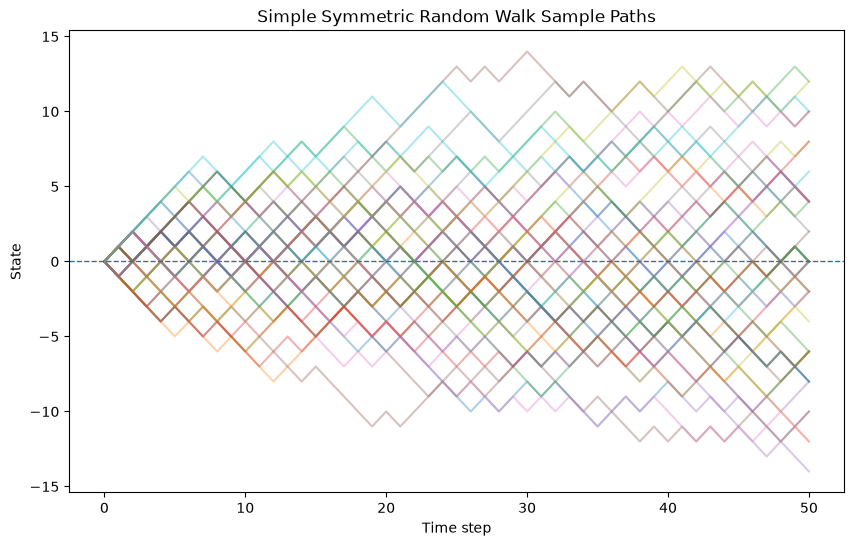

In [9]:
plt.figure(figsize=(10, 6))

for i in range(50):
    plt.plot(paths[i], alpha=0.35)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Simple Symmetric Random Walk Sample Paths")
plt.xlabel("Time step")
plt.ylabel("State")
plt.show()

## 4. Conditioning on current information

The martingale property is:

$$
\mathbb E[S_N \mid \mathcal F_n] = S_n
$$

This means that once the information up to time $n$ is known, the expected future value at time $N$ should equal the current value.

A common computational mistake is to filter historical simulated paths that happen to share the same state $S_n$. That estimates something closer to:

$$
\mathbb E[S_N \mid S_n]
$$

For a Markov process this can still work, but it does not clearly represent the full filtration $\mathcal F_n$.

Instead, this notebook freezes one realised history up to time $n$, then simulates many possible future branches from the known state $S_n$. This better represents the idea of conditioning on current information.

In [10]:
def branch_from_known_history(
    observed_path: np.ndarray,
    current_step: int,
    terminal_step: int,
    num_branches: int,
    p_up: float = 0.5
) -> np.ndarray:
    """
    Freeze a realised history up to current_step and simulate possible future branches.

    Parameters
    ----------
    observed_path:
        One realised path from time 0 to terminal_step.

    current_step:
        The time step at which information is frozen.

    terminal_step:
        The final time step.

    num_branches:
        Number of future continuations simulated from the known state.

    p_up:
        Probability of an upward step in the future branch.

    Returns
    -------
    future_paths:
        Array of future branches, each starting from the known state S_n.
    """
    if terminal_step <= current_step:
        raise ValueError("terminal_step must be greater than current_step.")

    if not 0 <= p_up <= 1:
        raise ValueError("p_up must be between 0 and 1.")

    known_state = observed_path[current_step]
    remaining_steps = terminal_step - current_step

    future_steps = rng.choice(
        [-1, 1],
        size=(num_branches, remaining_steps),
        p=[1 - p_up, p_up]
    )

    future_paths = np.zeros((num_branches, remaining_steps + 1))
    future_paths[:, 0] = known_state
    future_paths[:, 1:] = known_state + np.cumsum(future_steps, axis=1)

    return future_paths

In [11]:
current_step = 25
terminal_step = 50
num_branches = 50_000

observed_path = paths[0]

future_branches = branch_from_known_history(
    observed_path=observed_path,
    current_step=current_step,
    terminal_step=terminal_step,
    num_branches=num_branches,
    p_up=0.5
)

s_n = observed_path[current_step]
estimated_conditional_expectation = future_branches[:, -1].mean()
monte_carlo_error = estimated_conditional_expectation - s_n

print(f"S_n: {s_n:.4f}")
print(f"Estimated E[S_N | F_n]: {estimated_conditional_expectation:.4f}")
print(f"Monte Carlo error: {monte_carlo_error:.4f}")

S_n: 7.0000
Estimated E[S_N | F_n]: 6.9926
Monte Carlo error: -0.0074


## 5. Interpretation

The estimated conditional expectation should be close to $S_n$.

Any small difference is not a failure of the martingale property. It is Monte Carlo sampling error.

The error decreases as the number of simulated future branches increases.

The important point is that the past path is already known and fixed, while only the future increments remain random.

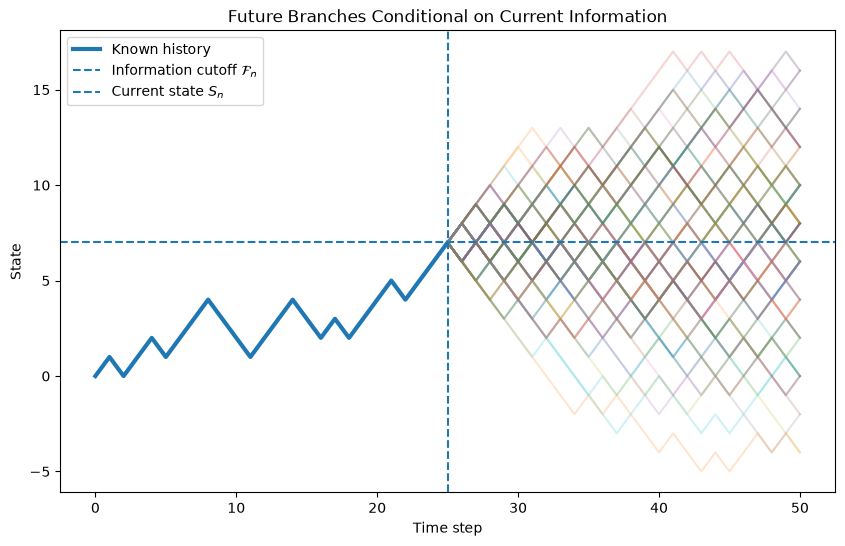

In [12]:
plt.figure(figsize=(10, 6))

# Plot the known history up to the filtration cutoff
plt.plot(
    range(current_step + 1),
    observed_path[:current_step + 1],
    linewidth=3,
    label="Known history"
)

# Plot possible future branches
future_time_grid = range(current_step, terminal_step + 1)

for i in range(100):
    plt.plot(
        future_time_grid,
        future_branches[i],
        alpha=0.20
    )

plt.axvline(current_step, linestyle="--", label=r"Information cutoff $\mathcal{F}_n$")
plt.axhline(s_n, linestyle="--", label=r"Current state $S_n$")
plt.title("Future Branches Conditional on Current Information")
plt.xlabel("Time step")
plt.ylabel("State")
plt.legend()
plt.show()

## 6. Martingale, submartingale, and supermartingale comparison

The symmetric random walk has:

$$
p_{\text{up}} = 0.5
$$

so each future increment has zero expectation.

If:

$$
p_{\text{up}} > 0.5
$$

then the process has positive drift and behaves like a submartingale.

If:

$$
p_{\text{up}} < 0.5
$$

then the process has negative drift and behaves like a supermartingale.

For a random walk with up-probability $p$, the expected increment is:

$$
\mathbb E[\xi] = 1(p) + (-1)(1-p) = 2p - 1
$$

Therefore, over $N-n$ remaining steps:

$$
\begin{aligned}
\mathbb E[S_N \mid \mathcal F_n] &= S_n + (N-n)(2p - 1)
\end{aligned}
$$

In [13]:
def classify_process(p_up: float) -> str:
    """
    Classify the random walk based on the expected increment.
    """
    if np.isclose(p_up, 0.5):
        return "Martingale"
    elif p_up > 0.5:
        return "Submartingale"
    else:
        return "Supermartingale"


comparison_rows = []

for p_up in [0.45, 0.50, 0.55]:
    branches = branch_from_known_history(
        observed_path=observed_path,
        current_step=current_step,
        terminal_step=terminal_step,
        num_branches=num_branches,
        p_up=p_up
    )

    empirical_expectation = branches[:, -1].mean()
    theoretical_expectation = s_n + (terminal_step - current_step) * (2 * p_up - 1)

    comparison_rows.append({
        "p_up": p_up,
        "process_type": classify_process(p_up),
        "S_n": s_n,
        "theoretical_E[S_N | F_n]": theoretical_expectation,
        "empirical_E[S_N | F_n]": empirical_expectation,
        "monte_carlo_error": empirical_expectation - theoretical_expectation
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,p_up,process_type,S_n,theoretical_E[S_N | F_n],empirical_E[S_N | F_n],monte_carlo_error
0,0.45,Supermartingale,7.0,4.5,4.45720,-0.04280
1,0.50,Martingale,7.0,7.0,7.01172,0.01172
2,0.55,Submartingale,7.0,9.5,9.50484,0.00484


## 7. Final comparison table

The table above gives a compact summary of the three cases:

| Process | Condition | Interpretation |
|---|---|---|
| Supermartingale | $p_{\text{up}} < 0.5$ | Expected future value is below the current value |
| Martingale | $p_{\text{up}} = 0.5$ | Expected future value equals the current value |
| Submartingale | $p_{\text{up}} > 0.5$ | Expected future value is above the current value |

This comparison is useful because it shows that the martingale property is not just a visual pattern. It is a precise statement about conditional expectation.

## 8. Financial interpretation

The simple symmetric random walk is not a realistic asset price model because:

1. it can become negative;
2. it has constant volatility;
3. it has independent increments;
4. it has no transaction costs, liquidity constraints, or market microstructure.

However, it is mathematically useful because it introduces the idea of a fair game under a given probability measure.

In finance, the key martingale result is not that real-world asset prices must be martingales under the physical probability measure $\mathbb P$.

Instead, the central pricing idea is:

$$
\begin{aligned}
\mathbb E^{\mathbb Q} \left[ \frac{S_T}{B_T} \mid \mathcal F_t \right] &= \frac{S_t}{B_t}
\end{aligned}
$$

where:

- $\mathbb Q$ is a risk-neutral measure;
- $B_t$ is the money-market account or risk-free numeraire;
- $\frac{S_t}{B_t}$ is the discounted asset price.

So the deeper financial statement is:

> Under a risk-neutral measure, discounted tradable asset prices should be martingales in an arbitrage-free model.

This is the bridge from probability theory to derivative pricing.

## 9. Limitations

This notebook is deliberately simplified.

### 9.1 Simple random walks can become negative

A random walk is not a good direct model for an equity price because prices cannot fall below zero.

Later notebooks will move towards geometric Brownian motion:

$$
dS_t = \mu S_t dt + \sigma S_t dW_t
$$

which keeps prices positive.

### 9.2 Constant volatility is unrealistic

The model assumes identically distributed increments with constant variance.

Real financial returns often show volatility clustering, meaning large moves tend to be followed by large moves and quiet periods tend to be followed by quiet periods.

### 9.3 The model is Markovian

The simple random walk only needs the current state to describe the distribution of future states.

However, many modern financial models are path-dependent or non-Markovian. In those models, the full history may matter, not just the current state.

### 9.4 No market frictions

The model ignores:

- bid-ask spreads;
- transaction costs;
- market impact;
- liquidity constraints;
- discrete hedging;
- funding costs.

These frictions become important when moving from theoretical pricing to realistic hedging and execution.

### 9.5 Physical measure vs risk-neutral measure

This notebook simulates processes under a chosen probability measure, but it does not yet construct the risk-neutral measure $\mathbb Q$.

That measure change is essential for arbitrage-free derivative pricing.

## 10. Research frontier and current directions

The basic martingale concept in this notebook connects to several active research and industry-relevant areas.

### 10.1 Martingale Optimal Transport

Classical derivative pricing requires a specific stochastic model for the underlying asset.

Martingale Optimal Transport asks a more robust question:

> What can be priced or hedged using only market-implied marginal distributions and the martingale constraint?

This is useful for model-independent pricing and robust hedging, especially when the exact dynamics of the underlying asset are uncertain.

A possible future notebook could implement a simple two-period martingale transport problem and compare model-dependent Black-Scholes prices with model-independent price bounds.

### 10.2 Arbitrage-free machine learning models

Many machine learning models can fit historical prices or option surfaces, but they may accidentally violate no-arbitrage constraints.

A modern research direction is to build neural models that are flexible but still respect financial structure, such as martingale constraints, admissible volatility surfaces, or no-static-arbitrage conditions.

A possible future notebook could test whether a fitted implied volatility surface violates basic no-arbitrage constraints.

### 10.3 Deep hedging under transaction costs

Classical martingale pricing assumes frictionless markets and continuous rebalancing.

In practice, hedging involves transaction costs, bid-ask spreads, liquidity limits, and risk constraints.

Deep hedging uses neural networks to learn hedging strategies directly under these frictions. This shifts the question from perfect replication to risk-controlled hedging under realistic constraints.

A possible future notebook could compare Black-Scholes delta hedging against a simple neural-network hedging rule under proportional transaction costs.

### 10.4 Rough volatility and non-Markovian models

The simple random walk is Markovian: the current state is enough to describe future probabilities.

Rough volatility models challenge this by allowing volatility to behave in a highly irregular and path-dependent way.

This matters because real volatility surfaces and high-frequency data often display behaviour that is difficult to capture with constant-volatility or simple Markov models.

A possible future notebook could simulate fractional Brownian motion or compare standard Brownian paths with rough-volatility-inspired paths.

### 10.5 Market generators

Another modern direction is the use of neural market generators to create synthetic but realistic market scenarios.

The danger is that a generator may match statistical patterns while violating economic constraints.

This connects back to the martingale idea: generated scenarios should not merely look realistic; they should also respect financial restrictions such as no-arbitrage where appropriate.

## 11. Suggested follow-up notebooks

This notebook naturally leads to:

1. **00_02_brownian_motion_simulation**  
   Scaling limits, Brownian motion, quadratic variation, and Donsker's theorem.

2. **02_01_discrete_martingale_pricing_shreve**  
   Applying martingales to binomial pricing and no-arbitrage arguments.

3. **02_02_crr_binomial_lattice**  
   Building an actual option-pricing tree using risk-neutral probabilities.

4. **02_03_black_scholes_merton_pde**  
   Moving from discrete time to continuous-time stochastic calculus.

5. **02_10_finite_difference_pde_pricer**  
   Numerically solving pricing equations using finite-difference methods.

6. **03_or_05_arbitrage_free_ml_constraints**  
   Testing whether machine learning models respect financial no-arbitrage conditions.

7. **06_deep_hedging_with_transaction_costs**  
   Studying hedging when the frictionless martingale-pricing assumptions no longer hold.

## 12. Summary

This notebook introduced filtrations and martingales in discrete time.

The main result was:

$$
\mathbb E[S_N \mid \mathcal F_n] = S_n
$$

for a simple symmetric random walk.

Computationally, this was tested by freezing an observed history up to time $n$, simulating many future branches, and estimating the conditional expectation at a later time $N$.

The notebook also compared martingales, submartingales, and supermartingales by changing the probability of an upward step.

The key financial takeaway is:

> Martingales are not just abstract fair-game objects. They are the mathematical language behind arbitrage-free pricing, risk-neutral valuation, and many modern extensions in robust finance, machine learning, and hedging under frictions.

## 13. Further reading

This section is intentionally short. It is included to signal the research directions connected to this foundational notebook.

- Shreve, S. E. *Stochastic Calculus for Finance I: The Binomial Asset Pricing Model.*
- Shreve, S. E. *Stochastic Calculus for Finance II: Continuous-Time Models.*
- Hobson, D. "The Skorokhod Embedding Problem and Model-Independent Bounds for Option Prices."
- Beiglböck, M., Henry-Labordère, P., and Penkner, F. "Model-independent bounds for option prices: a mass transport approach."
- Buehler, H., Gonon, L., Teichmann, J., and Wood, B. "Deep Hedging."